<a href="https://colab.research.google.com/github/asegura4488/EDCO_IntroCienciaDatos/blob/main/Semana4/RegresionLinealConceptos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
from google.colab import files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [13]:
# Necesitamos explorar la estructura de directorios
import os
# Necesito ir a la carpeta del curso
os.chdir('/content/drive/MyDrive/EDCO_IntroCienciaDatos/Semana5/')

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [15]:
# Problemas de regresion
data = pd.read_csv('Datos/DatosRegresion.csv')
data

,X0,X1,Y
0,5.488135,6.207617,25.523276
1,7.151894,7.460697,32.167177
2,6.027634,10.499409,43.066154
3,5.448832,15.011900,38.069097
4,4.236548,6.670149,21.101511
...,...,...,...
495,2.716528,1.953527,5.693810
496,4.554441,10.298444,28.084859
497,4.017135,18.768240,51.312559
498,2.484135,4.572931,18.596668


In [16]:
X = np.array(data[['X0','X1']])
Y = np.array(data['Y'])

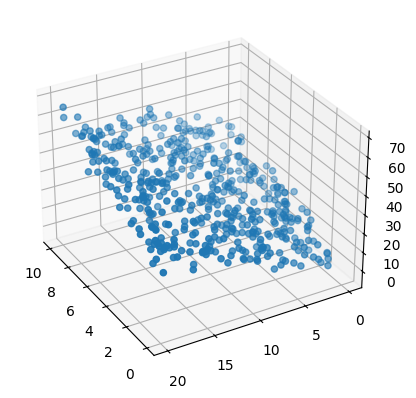

In [17]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d', elev=30, azim=150)
ax.scatter(X[:,0], X[:,1], Y)
plt.show()

In [18]:
# Queremos encontra el modelo, que es una aproximacion lineal a la nube de datos
XTrain, XTest, YTrain, YTest = train_test_split(X, Y, test_size=0.2, random_state=42)

In [19]:
# Modelo
Model = LinearRegression()
Model.fit(XTrain, YTrain)

LinearRegression()

In [20]:
Model.intercept_

np.float64(3.770760603399548)

In [21]:
Model.coef_[0]

np.float64(2.4738169495486084)

In [22]:
Model.coef_[1]

np.float64(1.4807416623384977)

In [23]:
params = np.array([Model.intercept_,Model.coef_[0],Model.coef_[1]])
params

array([3.7707606 , 2.47381695, 1.48074166])

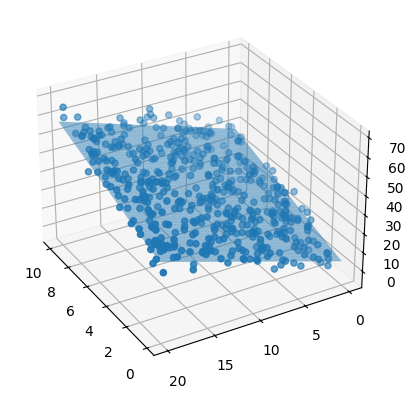

In [24]:
x0 = np.linspace(min(X[:,0]),max(X[:,0]),100)
x1 = np.linspace(min(X[:,1]),max(X[:,1]),100)
xx0,xx1 = np.meshgrid(x0,x1)

YModelo = params[0] + params[1]*xx0 + params[2]*xx1


fig = plt.figure()
ax = fig.add_subplot(projection='3d', elev=30, azim=150)
ax.scatter(X[:,0], X[:,1], Y)
ax.plot_surface(xx0,xx1,YModelo, alpha=0.5)
plt.show()